In [1]:
pip install -U finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.1 MB/s eta 0:00:00


In [2]:
# mq_quant.py

import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

def get_close(ticker, start, end=None):
    """
    종가 데이터 수집 (Get Close Prices)
    """
    return fdr.DataReader(ticker, start, end)['Close']

def calc_daily_return(prices):
    """
    일별 수익률 계산 (Calculate Daily Returns)
    """
    return prices.pct_change().fillna(0)

def calc_cum_return(prices):
    """
    누적 수익률(자산 흐름) 계산 (Calculate Cumulative Returns)
    """
    return prices / prices.iloc[0]

def calc_portfolio(prices, weight=None):
    """
    포트폴리오 수익률 계산 (Calculate Portfolio Returns)
    returns: (일별 수익률, 누적 수익률)
    """
    # 1. 누적 수익률 계산
    cum_ret = calc_cum_return(prices)

    # 2. 비중 설정 (기본값: 동일 비중)
    if not weight:
        weight = [1/len(prices.columns)] * len(prices.columns)

    # 3. 포트폴리오 누적 수익률 (가중 평균)
    # 각 자산의 누적 수익률에 비중을 곱해 합산합니다. (Buy & Hold 가정)
    port_cum_ret = (cum_ret * weight).sum(axis=1)

    # 4. 포트폴리오 일별 수익률 (역산)
    port_daily_ret = port_cum_ret.pct_change().fillna(0)

    return port_daily_ret, port_cum_ret


def evaluate_performance(daily_ret, cum_ret, risk_free_rate=0.02):
    """
    성과 지표 평가 (CAGR, MDD, Volatility, Sharpe ratio)
    """

    # 1. 수익성 (CAGR)
    total_ret = cum_ret.iloc[-1]
    years = len(cum_ret) / 252
    cagr = total_ret ** (1 / years) - 1

    # 2. 안정성 (MDD)
    historical_max = cum_ret.cummax()
    dd = (cum_ret - historical_max) / historical_max * 100
    mdd = dd.min()

    # 3. 위험 (변동성)
    daily_vol = daily_ret.std()               # 일일 변동성
    annual_vol = daily_vol * np.sqrt(252)     # 연간 변동성

    # 4. 효율 (Sharpe Ratio)
    annual_return = daily_ret.mean() * 252    # 연간 수익률 (산술 평균)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_vol # 위험 한 단위당 수익

    print(f"▶ 최종 수익률   : {(cum_ret.iloc[-1]-1)*100:.2f}%")
    print(f"=== 성과 평가 리포트 ===")
    print(f"1. 수익성 (CAGR) : {cagr*100:.2f}%")
    print(f"2. 안정성 (MDD)  : {mdd:.2f}%")
    print(f"-" * 30)
    print(f"3. 연간 변동성   : {annual_vol*100:.2f}%")
    print(f"4. 샤프 지수     : {sharpe_ratio:.4f}")

    return cagr, dd, mdd

def get_rebalancing_dates(close_data, period="month"):
    """
    리밸런싱 날짜 추출 (Pandas Grouper 활용)
    - 입력: 종가 데이터, 주기('month', 'quarter', 'year')
    - 출력: 리밸런싱 시행일(DatetimeIndex)
    """
    # 주기별 Pandas Frequency 문자열 매핑
    freq_map = {'month': 'ME', 'quarter': 'QE', 'year': 'YE'}

    # 1. 예외처리: 잘못된 주기 입력
    if period not in freq_map:
        raise ValueError("period must be 'month', 'quarter', or 'year'")

    freq = freq_map[period]

    rebalancing_dates = close_data.groupby(pd.Grouper(freq=freq)).apply(lambda x: x.index[-1])

    return rebalancing_dates.sort_index()


def cal_rebalancing_portfolio(close_data, period="month", weight_df=None, enable_plot=True):
    """
    리밸런싱 포트폴리오 성과 계산 (Chunk 방식)
    """

    # 1. 리밸런싱 날짜 구하기 (전체 데이터 기준)
    rebal_dates = get_rebalancing_dates(close_data, period)

    # 날짜 동기화 (weight_df가 있다면, 교집합 날짜만 사용)
    # close_data가 더 길어도, weight_df가 있는 기간만 백테스팅 수행
    if weight_df is not None:
        # weight_df 인덱스에 포함된 날짜만 필터링
        rebal_dates = rebal_dates[rebal_dates.isin(weight_df.index)]

        # 만약 겹치는 날짜가 하나도 없다면 에러 처리
        if rebal_dates.empty:
            print("Error: close_data와 weight_df의 리밸런싱 날짜가 일치하지 않습니다.")
            return None, None

    # 3. 초기 비중 설정 (없으면 동일 비중)
    if weight_df is None:
        n_assets = len(close_data.columns)
        weight_df = pd.DataFrame(
            index=rebal_dates,
            columns=close_data.columns,
            data=1/n_assets
        )

    # 4. 데이터 범위 보정 (시작일 기준)
    first_date = rebal_dates[0] # 필터링된 첫 날짜


    # 전체 기간 수익률 계산
    full_daily_rets = close_data.pct_change().fillna(0)

    # 백테스트 시작일 이후 데이터만 슬라이싱
    daily_rets = full_daily_rets.loc[first_date:]

    portfolio_chunks = []
    total_value = 1.0

    # 리밸런싱 기간별 순회
    full_dates = list(rebal_dates)

    # 마지막 구간 처리: 마지막 리밸런싱 날짜 ~ 데이터 끝 날짜
    # (단, daily_rets의 마지막 날짜가 리밸런싱 날짜보다 뒤에 있을 때만)
    if full_dates[-1] < daily_rets.index[-1]:
        full_dates.append(daily_rets.index[-1])

    for start, end in zip(full_dates[:-1], full_dates[1:]):

        # start가 weight_df에 없으면 건너뜀 (안전 장치)
        if start not in weight_df.index:
            continue

        current_weights = weight_df.loc[start]

        # start 다음날부터 end까지의 수익률 사용 (start 당일은 리밸런싱 날)
        chunk_rets = daily_rets.loc[start:end].iloc[1:]

        if chunk_rets.empty: continue

        cum_growth = (1 + chunk_rets).cumprod()
        chunk_value = (cum_growth * current_weights).sum(axis=1) * total_value
        portfolio_chunks.append(chunk_value)
        total_value = chunk_value.iloc[-1]

    # 6. 결과 병합
    if not portfolio_chunks:
        return None, None

    portfolio_cum_ret = pd.concat(portfolio_chunks)
    portfolio_cum_ret.loc[first_date] = 1.0 # 시작점 1.0 강제 할당
    portfolio_cum_ret = portfolio_cum_ret.sort_index()

    portfolio_day_ret = portfolio_cum_ret.pct_change().fillna(0)

    if enable_plot:
        historical_max = portfolio_cum_ret.cummax()
        dd = (portfolio_cum_ret - historical_max) / historical_max * 100
        mdd = dd.min()

        # [수정] 전체 컬럼이 아니라, weight_df에 존재하는(실제 투자된) 티커만 추출
        if weight_df is not None:
            # weight_df의 컬럼 중 close_data에도 존재하는 것만 리스트로 만듦 (KeyError 방지)
            tickers = [col for col in weight_df.columns if col in close_data.columns]

            if 'cash' in tickers: tickers.remove('cash')
        else:
            tickers = close_data.columns.tolist()

        plot_daily_rets = full_daily_rets.loc[portfolio_cum_ret.index]

        plot_portfolio_result(tickers, plot_daily_rets, portfolio_cum_ret, dd, mdd)

    return portfolio_day_ret, portfolio_cum_ret


def plot_portfolio_result(tickers, daily_rets, port_cum_ret, dd, mdd):
    """
    포트폴리오 성과 시각화 함수 (백테스트 기간 일치 버전)
    """

    plt.figure(figsize=(10, 8))

    # [차트 1] 포트폴리오 누적 수익률 (Asset Growth)
    plt.subplot(2, 1, 1)

    # 1. 메인 포트폴리오 선 그리기
    plt.plot(port_cum_ret.index, port_cum_ret, label='Portfolio', color='#d62728', linewidth=1.5)

    # 2. 개별 종목 흐름 그리기 (기간 매칭 및 리베이스)
    if daily_rets is not None and tickers is not None:

        # [핵심 수정] 포트폴리오의 시작/종료 날짜 구하기
        start_date = port_cum_ret.index[0]
        end_date = port_cum_ret.index[-1]

        # [핵심 수정] 전체 데이터(daily_rets)를 실제 백테스트 기간만큼만 자르기
        subset_daily_rets = daily_rets.loc[start_date:end_date]

        for t in tickers:
            if t in subset_daily_rets.columns:
                # [핵심 수정] 잘라낸 기간의 수익률로 누적 수익률 새로 계산
                # 이렇게 해야 시작점이 1.0(혹은 포트폴리오 시작점) 근처로 맞춰집니다.
                ind_cum = (1 + subset_daily_rets[t]).cumprod()

                # 시각화 (투명도 조절)
                plt.plot(ind_cum.index, ind_cum, label=f'{t}', alpha=0.3, linewidth=0.8, linestyle='--')

    # Y축 로그 스케일 및 포맷 설정
    plt.yscale('log')
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')

    plt.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
    plt.title('Portfolio Cumulative Return', fontsize=14, fontweight='bold')

    # 범례가 너무 많으면 가리니까, 적절히 위치 조정
    plt.legend(loc='upper left', fontsize='small')
    plt.grid(True, alpha=0.3)


    # [차트 2] 낙폭 (Drawdown)
    plt.subplot(2, 1, 2)

    plt.fill_between(dd.index, dd, 0, color='#1f77b4', alpha=0.3)
    plt.plot(dd.index, dd, color='#1f77b4', linewidth=0.5)

    plt.title('Portfolio Drawdown (MDD)', fontsize=12)
    plt.axhline(mdd, color='red', linestyle='--', label=f'Max DD: {mdd:.2f}%')

    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.ylabel('Drawdown (%)')

    plt.tight_layout()
    plt.show()


def cal_AvgMomentumScore(close_data, n = 12):
    """
    평균 모멘텀 스코어를 기반으로 한 투자 비중 구하기
    close_data: 종가 데이터
    n: 모멘텀 기간 1~n
    return: 투자비중 weight df, 평균모멘텀 스코어 df
    """
    avgMomentumScore = 0 # 평모스 초기값
    priceOnRebalDate = close_data.loc[get_rebalancing_dates(close_data)] # 리밸런싱 일자의 가격 데이터

    # 1 ~ n개월 모멘텀 스코어 합
    for i in range(1, n+1):
        avgMomentumScore = np.where(priceOnRebalDate / priceOnRebalDate.shift(i) > 1, 1, 0) + avgMomentumScore

    # 평모스 계산
    avgMomentumScore = pd.DataFrame(avgMomentumScore, index=priceOnRebalDate.index, columns=priceOnRebalDate.columns) # dataframe 형변환
    avgMomentumScore = avgMomentumScore / n

    # 모멘텀 스코어에 따른 weight 계산
    weight = avgMomentumScore.divide(avgMomentumScore.sum(axis=1), axis=0).fillna(0)
    # 투자 비중이 모두 0인 구간에서는 현금 보유
    weight['cash'] = np.where(weight.sum(axis=1) == 0, 1, 0)

    # 투자비중, 평모스 리턴
    return weight, avgMomentumScore

def get_heatmap(cumReturn):
    """
    cagr, dd, mdd 계산 및 히트맵(연간/월간 수익률) 시각화
    """
    # 1. CAGR 계산
    cagr = cumReturn.iloc[-1] ** (252/len(cumReturn))

    # 2. MDD 계산
    dd = (cumReturn.cummax() - cumReturn) / cumReturn.cummax() * 100
    mdd = dd.max()

    print(f"최종수익률: {cumReturn.iloc[-1]:.4f}\ncagr: {cagr:.4f}\nmdd: {mdd:.4f}%")

    # 3. 데이터프레임 변환 및 전처리
    cumReturn = pd.DataFrame(cumReturn)
    cumReturn.columns = ['cumReturn']
    cumReturn['year'] = cumReturn.index.year
    cumReturn['month'] = cumReturn.index.month

    # 월별/연별 마지막 데이터만 추출
    monthData = cumReturn.drop_duplicates(['year', 'month'], keep="last").copy()
    yearData = cumReturn.drop_duplicates('year', keep="last").copy()

    # 4. 수익률 계산
    monthData['monthReturn'] = monthData['cumReturn'].pct_change().fillna(0) * 100
    # 연간 수익률
    yearData['yearReturn'] = yearData['cumReturn'].pct_change().fillna(0) * 100
    # 첫 해 수익률 보정 (1.0에서 시작했다고 가정)
    yearData.iloc[0, -1] = (yearData.iloc[0, 0] - 1) * 100

    # 시각화를 위해 마지막 데이터의 '월'을 강제로 12로 설정 (연간 수익률 히트맵 정렬용)
    yearData.iloc[-1, yearData.columns.get_loc('month')] = 12

    # 5. 히트맵 시각화
    # 피벗 테이블 생성
    monthPivot = monthData.pivot(index='year', columns='month', values='monthReturn')
    yearPivot = yearData.pivot(index='year', columns='month', values='yearReturn')

    # 그래프 그리기
    # width_ratios=[1, 5]: 연간 수익률(왼쪽)은 좁게, 월간 수익률(오른쪽)은 넓게 설정
    f, (ax1, ax2) = plt.subplots(1, 2, sharey=True, gridspec_kw={'width_ratios': [1, 5]}, figsize=(20, 10))

    # 왼쪽: 연간 수익률
    sns.heatmap(yearPivot, ax=ax1, annot=True, fmt='.2f', linewidths=.3, cmap="RdYlGn", center=0, cbar=False)
    ax1.set_title("Annual Return")

    # 오른쪽: 월간 수익률
    sns.heatmap(monthPivot, ax=ax2, annot=True, fmt='.2f', linewidths=.1, cmap="RdYlGn", center=0, cbar=False)
    ax2.set_title("Monthly Return")

    plt.tight_layout()
    plt.show()

### 월별, 연별 수익률 시각화

In [ ]:
kodex200 = get_close("069500", "2013") # 코스피200 ETF
kodex10Bond = get_close("152380", "2013") # kodex 국고채 10년물 etf

close_data = pd.concat([kodex200, kodex10Bond], axis=1)
close_data.columns = ['kodex200', 'kodex10Bond']
close_data.dropna(inplace=True)
close_data['cash'] = 1
close_data

,kodex200,kodex10Bond,cash
Date,,,
2013-10-29,21439,54397,1
2013-10-30,21522,54481,1
2013-10-31,21197,54362,1
2013-11-01,21254,54189,1
2013-11-04,21088,54051,1
...,...,...,...
2026-01-12,67610,67685,1
2026-01-13,68465,67470,1
2026-01-14,68840,67495,1


In [ ]:
# 비중
weight, avgMomentumScore = cal_AvgMomentumScore(close_data, n=12)
weight

,kodex200,kodex10Bond,cash
Date,,,
2013-10-31,0.00,0.00,1
2013-11-29,1.00,0.00,0
2013-12-30,0.00,1.00,0
2014-01-29,0.00,1.00,0
2014-02-28,0.20,0.80,0
...,...,...,...
2025-09-30,0.75,0.25,0
2025-10-31,0.80,0.20,0
2025-11-28,1.00,0.00,0


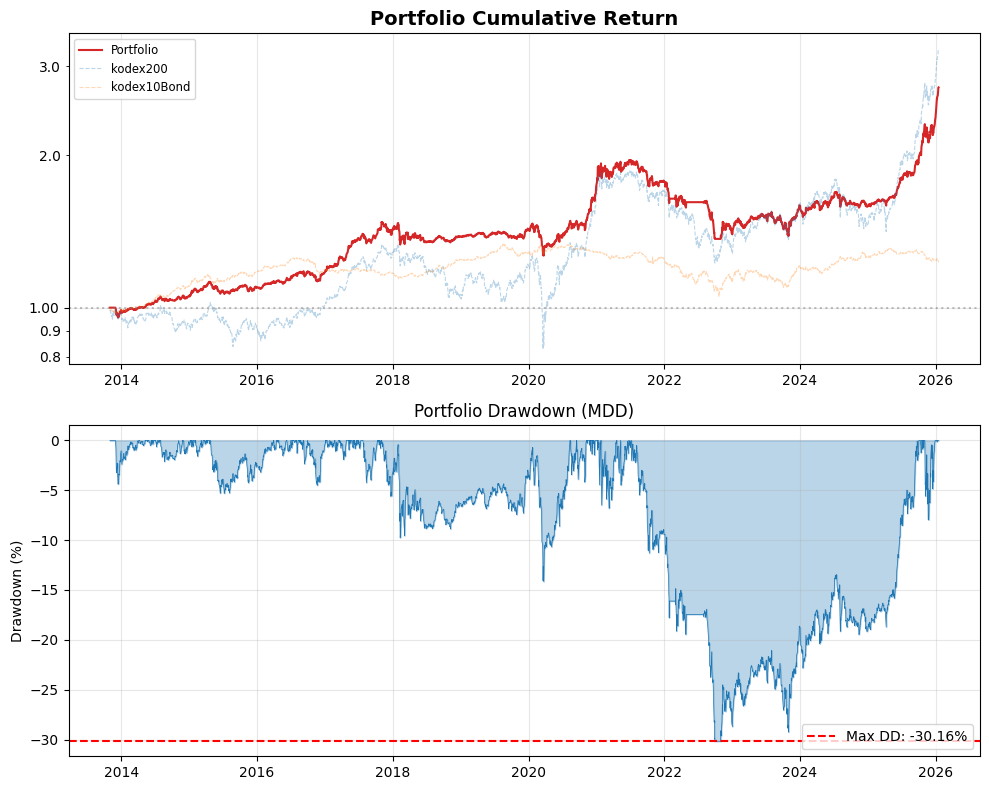

▶ 최종 수익률   : 172.68%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 8.80%
2. 안정성 (MDD)  : -30.16%
------------------------------
3. 연간 변동성   : 9.99%
4. 샤프 지수     : 0.6939


In [ ]:
dayReturn, cumReturn = cal_rebalancing_portfolio(close_data=close_data, weight_df=weight)
cagr, dd, mdd = evaluate_performance(dayReturn, cumReturn)

In [ ]:
cumReturn = pd.DataFrame(cumReturn, columns=["cumReturn"])
cumReturn

,cumReturn
Date,
2013-10-31,1.000000
2013-11-01,1.000000
2013-11-04,1.000000
2013-11-05,1.000000
2013-11-06,1.000000
...,...
2026-01-12,2.630083
2026-01-13,2.663343
2026-01-14,2.677931


In [ ]:
cumReturn['year'] = cumReturn.index.year
cumReturn['month'] = cumReturn.index.month

In [ ]:
cumReturn

,cumReturn,year,month
Date,,,
2013-10-31,1.000000,2013,10
2013-11-01,1.000000,2013,11
2013-11-04,1.000000,2013,11
2013-11-05,1.000000,2013,11
2013-11-06,1.000000,2013,11
...,...,...,...
2026-01-12,2.630083,2026,1
2026-01-13,2.663343,2026,1
2026-01-14,2.677931,2026,1


**월말, 연말 누적 수익률 추출**

In [ ]:
# 매월 말 누적수익률만 추출
monthData = cumReturn.drop_duplicates(['year', 'month'], keep="last").copy()
monthData

,cumReturn,year,month
Date,,,
2013-10-31,1.000000,2013,10
2013-11-29,1.000000,2013,11
2013-12-30,0.989714,2013,12
2014-01-29,0.984831,2014,1
2014-02-28,0.997395,2014,2
...,...,...,...
2025-09-30,1.931119,2025,9
2025-10-31,2.251672,2025,10
2025-11-28,2.164829,2025,11


In [ ]:
# 매년 말 누적 수익률만 추출
yearData = cumReturn.drop_duplicates('year', keep="last").copy()
yearData

,cumReturn,year,month
Date,,,
2013-12-30,0.989714,2013,12
2014-12-30,1.055065,2014,12
2015-12-30,1.096895,2015,12
2016-12-29,1.174138,2016,12
2017-12-28,1.426534,2017,12
2018-12-28,1.384182,2018,12
2019-12-30,1.430615,2019,12
2020-12-30,1.736469,2020,12
2021-12-30,1.773741,2021,12


**월간, 연간 수익률 계산**

`n월 월간 수익률 = n월 누적 수익률 / (n-1)월 누적수익률 = n월 가격 / (n-1)월 가격`
  
왜?

`n월 누적수익률 = n월 가격 / k`  
`k=투자 시작 시점 가격`

In [ ]:
# 월간수익률 계산
monthData["monthReturn"] = ((monthData['cumReturn'] / monthData['cumReturn'].shift(1).fillna(1))-1)*100
# pct_change() 함수를 사용해도됌
# monthData["monthReturn"] = monthData['cumReturn'].pct_change().fillna(0) * 100
monthData

,cumReturn,year,month,monthReturn
Date,,,,
2013-10-31,1.000000,2013,10,0.000000
2013-11-29,1.000000,2013,11,0.000000
2013-12-30,0.989714,2013,12,-1.028614
2014-01-29,0.984831,2014,1,-0.493394
2014-02-28,0.997395,2014,2,1.275813
...,...,...,...,...
2025-09-30,1.931119,2025,9,4.686974
2025-10-31,2.251672,2025,10,16.599350
2025-11-28,2.164829,2025,11,-3.856800


In [ ]:
# 연간수익률 계산
yearData["yearReturn"] = ((yearData['cumReturn'] / yearData['cumReturn'].shift(1).fillna(1)) -1)*100
yearData

,cumReturn,year,month,yearReturn
Date,,,,
2013-12-30,0.989714,2013,12,-1.028614
2014-12-30,1.055065,2014,12,6.602989
2015-12-30,1.096895,2015,12,3.964732
2016-12-29,1.174138,2016,12,7.041987
2017-12-28,1.426534,2017,12,21.496289
2018-12-28,1.384182,2018,12,-2.968919
2019-12-30,1.430615,2019,12,3.354564
2020-12-30,1.736469,2020,12,21.379166
2021-12-30,1.773741,2021,12,2.146454


In [ ]:
(monthData.loc['2014', "monthReturn"]/100+1).cumprod()

,monthReturn
Date,
2014-01-29,0.995066
2014-02-28,1.007761
2014-03-31,1.010131
2014-04-30,1.008961
2014-05-30,1.027487
2014-06-30,1.037574
2014-07-31,1.059818
2014-08-29,1.051823
2014-09-30,1.046563


**Pivot Table**

합계, 평균 등 다양한 수치를 보기 쉽게 정리한 테이블

히트맵을 그리기 위해 데이터를 행(Year) × 열(Month) 구조의 표로 재배치합니다.

In [ ]:
monthPivot = monthData.pivot(index='year', columns='month', values='monthReturn') # 월간수익률 피봇테이블
monthPivot

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,-1.028614
2014,-0.493394,1.275813,0.235183,-0.115882,1.836182,0.981722,2.143798,-0.754364,-0.500103,1.232769,0.786703,-0.165692
2015,3.144769,-0.470933,1.865393,0.483480,-0.804008,-1.998807,-0.874245,1.164178,2.017851,0.167408,-1.565329,0.896968
2016,0.053759,1.721854,0.988881,0.011210,-0.282528,1.850412,1.619050,0.609814,0.503811,-1.406608,-1.844934,3.107833
2017,2.626116,0.464155,3.710521,1.892611,5.155166,1.697897,0.535823,-1.336287,1.614726,5.387092,-2.515008,0.699142
2018,2.046763,-5.983327,0.886092,1.714457,-2.970510,-1.191336,0.340386,2.085181,-0.271558,-1.618295,1.420025,0.855233
2019,0.352030,0.050423,0.650126,0.518779,-1.344963,1.275112,0.102157,0.081624,-1.562132,-0.981268,0.520216,3.745744
2020,-1.392963,-2.254864,-4.021967,0.392201,1.964584,1.870023,3.813102,0.474977,0.965332,-2.085849,9.110328,11.835535
2021,3.882459,1.412147,1.155067,1.832806,1.098019,2.653756,-2.083462,-0.783095,-3.663930,-3.200435,-1.894887,2.047543


In [ ]:
yearPivot = yearData.pivot(index='year', columns='month', values='yearReturn') # 연간수익률 피봇테이블
yearPivot

month,1,12
year,,
2013,NaN,-1.028614
2014,NaN,6.602989
2015,NaN,3.964732
2016,NaN,7.041987
2017,NaN,21.496289
2018,NaN,-2.968919
2019,NaN,3.354564
2020,NaN,21.379166
2021,NaN,2.146454


**seaborn 히트맵**  
https://seaborn.pydata.org/examples/spreadsheet_heatmap.html

In [ ]:
import seaborn as sns
sns.set_theme()

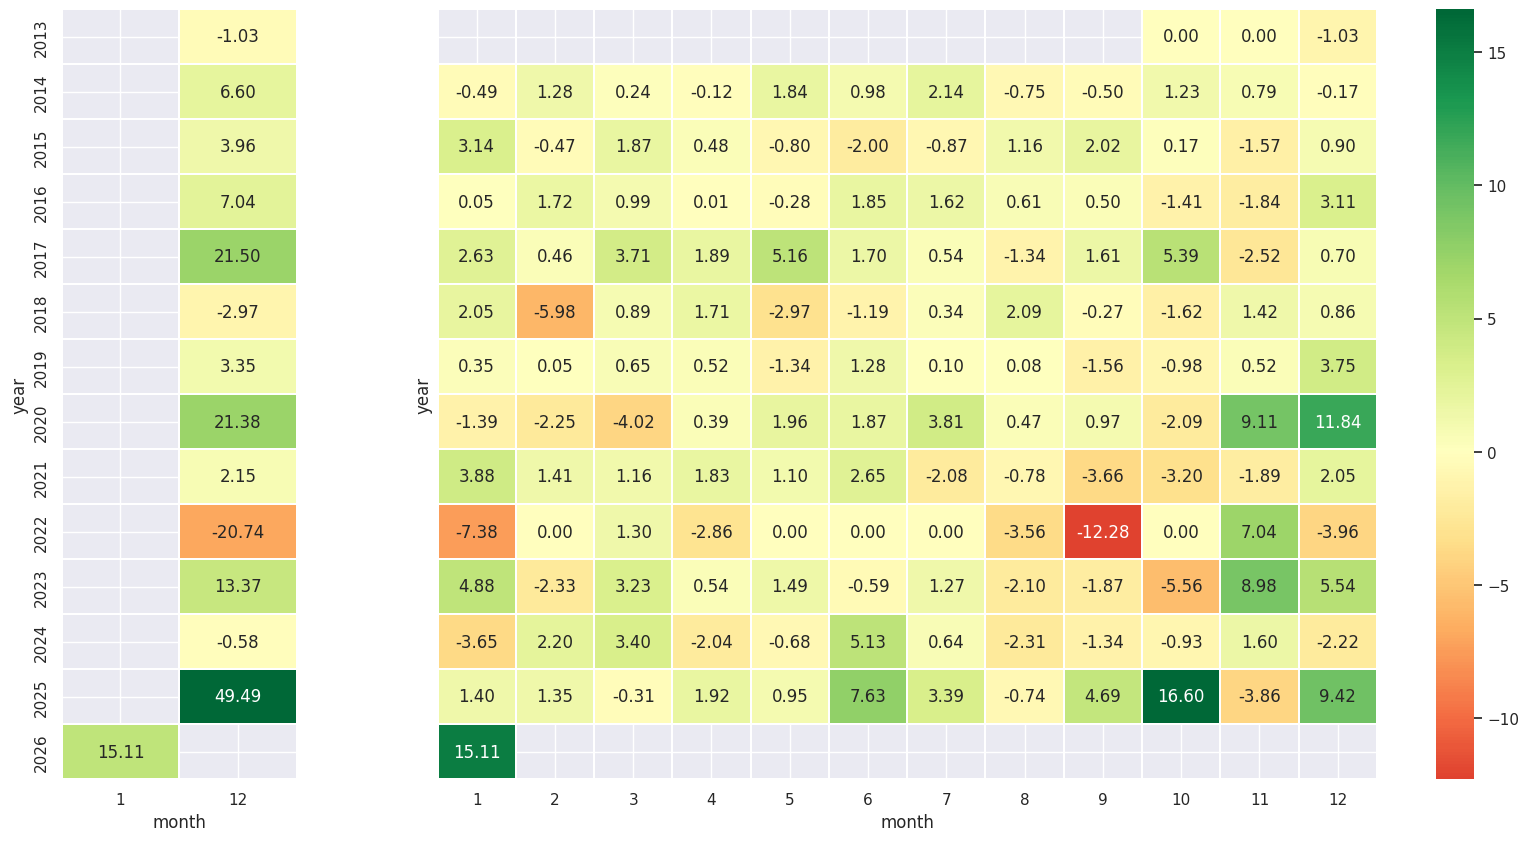

In [ ]:
# 그림판(figure) 크기 설정 (좌측: 연간 수익률, 우측: 월간 수익률)
# width_ratios=[1, 10]: 오른쪽 그림을 왼쪽보다 10배 넓게 그림
# annot=True: 칸 안에 숫자(수익률)를 표시해라.
# cmap="RdYlGn": 색상 테마 (Red-Yellow-Green). 초록색이 수익(+), 빨간색이 손실(-).
# center=0: 0%를 기준으로 색상을 나눈다. (0보다 크면 초록, 작으면 빨강)


f,(ax1,ax2) = plt.subplots(1,2, sharey=True, gridspec_kw={'width_ratios': [1, 5]}, figsize=(20, 10))
g1 = sns.heatmap(yearPivot, ax=ax1,annot=True, fmt='.2f',linewidths=.1, cmap="RdYlGn", center=0, cbar=False)
g2 = sns.heatmap(monthPivot,ax=ax2, annot=True, fmt='.2f',linewidths=.1, cmap="RdYlGn", center=0, cbar=True)

### 월간, 연간 수익률 시각화 함수화

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_heatmap(cumReturn):
    """
    cagr, dd, mdd 계산 및 히트맵(연간/월간 수익률) 시각화
    """
    cagr = cumReturn.iloc[-1] ** (252/len(cumReturn))
    dd = (cumReturn.cummax() - cumReturn) / cumReturn.cummax() * 100
    mdd = dd.max()

    print(f"최종수익률: {cumReturn.iloc[-1]:.4f}\ncagr: {cagr:.4f}\nmdd: {mdd:.4f}%")

    # 데이터프레임 변환 및 전처리
    cumReturn = pd.DataFrame(cumReturn)
    cumReturn.columns = ['cumReturn']
    cumReturn['year'] = cumReturn.index.year
    cumReturn['month'] = cumReturn.index.month

    # 월별/연별 마지막 데이터만 추출
    monthData = cumReturn.drop_duplicates(['year', 'month'], keep="last").copy()
    yearData = cumReturn.drop_duplicates('year', keep="last").copy()

    # 수익률 계산
    monthData['monthReturn'] = monthData['cumReturn'].pct_change().fillna(0) * 100
    # 연간 수익률
    yearData['yearReturn'] = yearData['cumReturn'].pct_change().fillna(0) * 100
    # 첫 해 수익률 보정 (1.0에서 시작했다고 가정)
    yearData.iloc[0, -1] = (yearData.iloc[0, 0] - 1) * 100

    # 시각화를 위해 마지막 데이터의 '월'을 강제로 12로 설정 (연간 수익률 히트맵 정렬용)
    yearData.iloc[-1, yearData.columns.get_loc('month')] = 12

    # 히트맵 시각화, 피벗 테이블 생성
    monthPivot = monthData.pivot(index='year', columns='month', values='monthReturn')
    yearPivot = yearData.pivot(index='year', columns='month', values='yearReturn')

    # 그래프 그리기
    # width_ratios=[1, 5]: 연간 수익률(왼쪽)은 좁게, 월간 수익률(오른쪽)은 넓게 설정
    f, (ax1, ax2) = plt.subplots(1, 2, sharey=True, gridspec_kw={'width_ratios': [1, 5]}, figsize=(20, 10))

    # 왼쪽: 연간 수익률
    sns.heatmap(yearPivot, ax=ax1, annot=True, fmt='.2f', linewidths=.3, cmap="RdYlGn", center=0, cbar=False)
    ax1.set_title("Annual Return")

    # 오른쪽: 월간 수익률
    sns.heatmap(monthPivot, ax=ax2, annot=True, fmt='.2f', linewidths=.1, cmap="RdYlGn", center=0, cbar=False)
    ax2.set_title("Monthly Return")

    plt.tight_layout()
    plt.show()

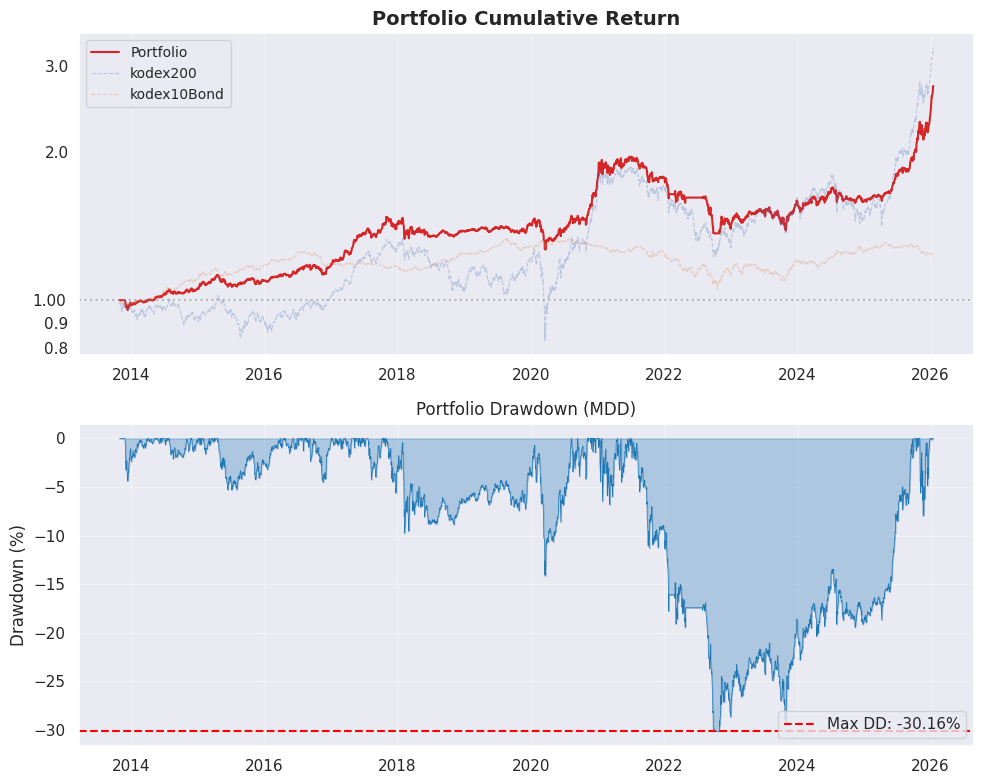

최종수익률: 2.7268
cagr: 1.0880
mdd: 30.1626%


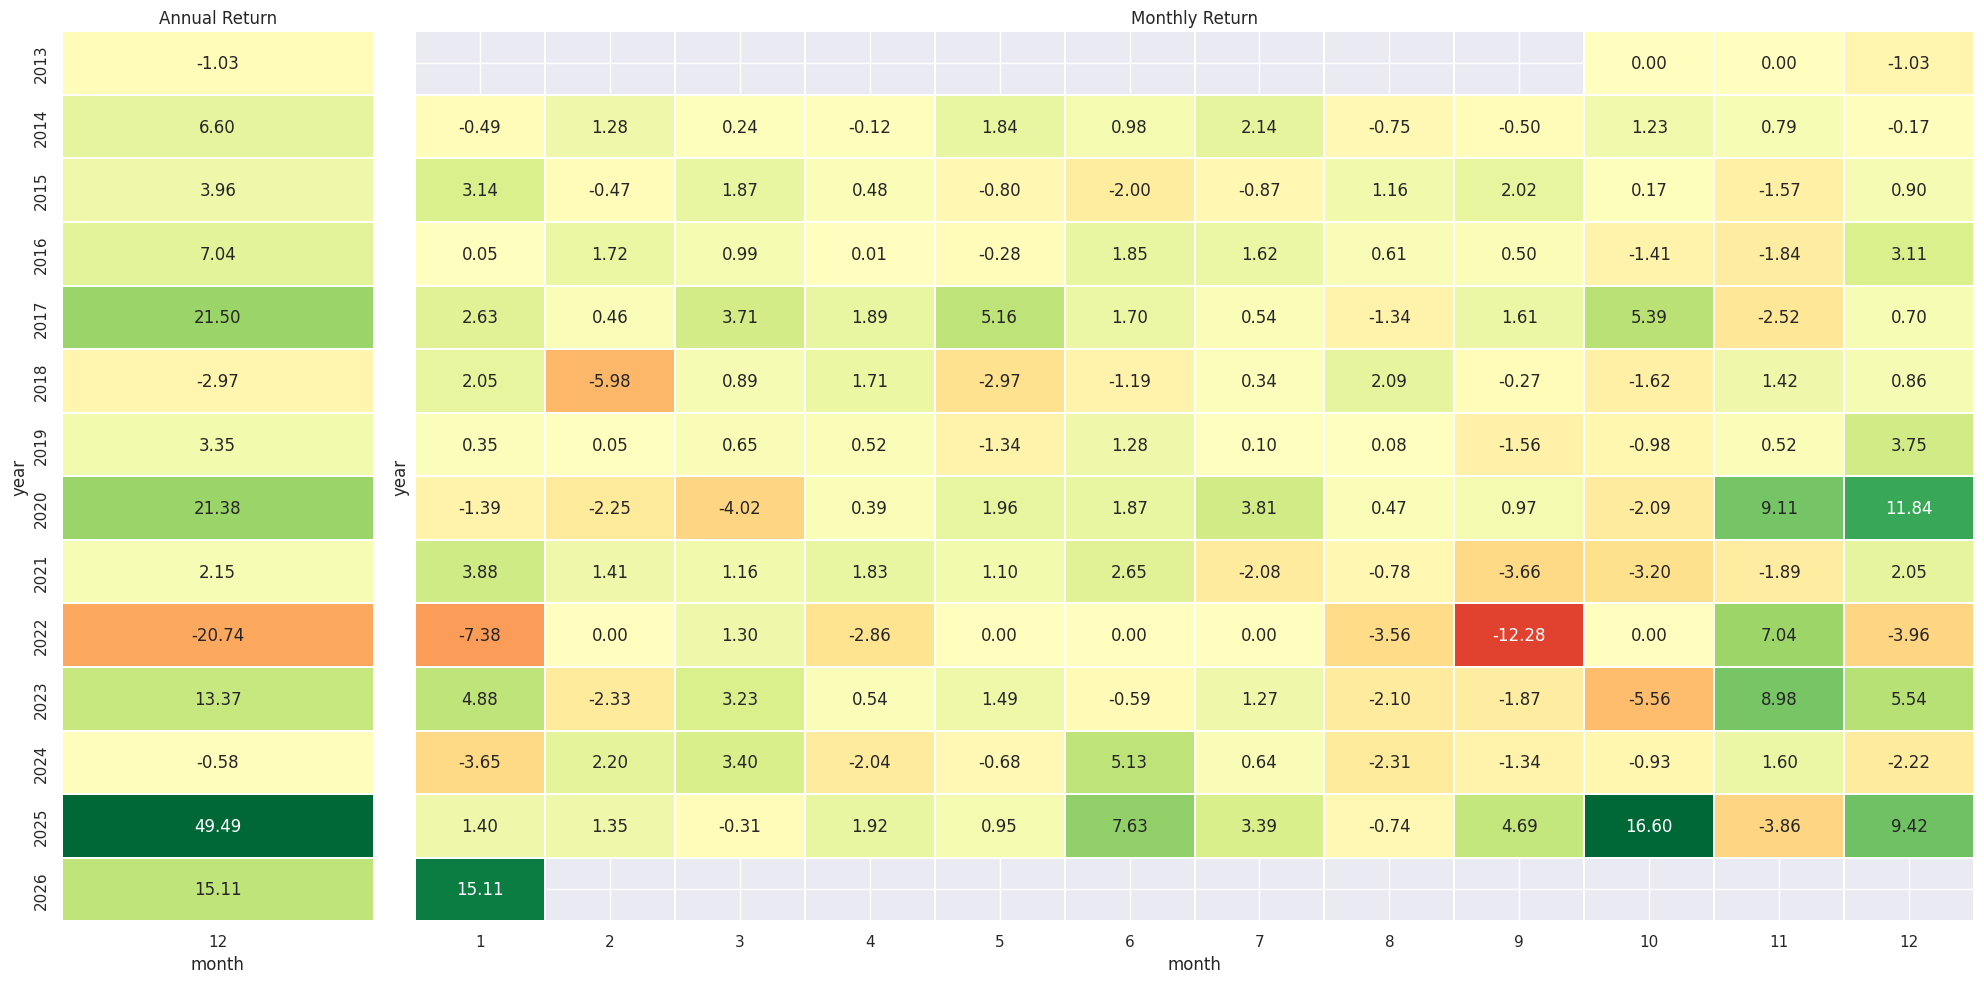

In [ ]:
_, cumReturn = cal_rebalancing_portfolio(close_data, weight_df=weight)
_ = get_heatmap(cumReturn)

직관적으로 수익률을 확인할 수 있고, 계절성을 파악하기에 용이합니다.   

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yfinance as yf

def get_heatmap(cumReturn):
    """
    cagr, dd, mdd 계산 및 히트맵(연간/월간 수익률) 시각화
    """
    # 데이터가 비어있지 않은지 확인
    if cumReturn.empty:
        print("데이터가 없습니다.")
        return

    cagr = cumReturn.iloc[-1] ** (252/len(cumReturn))
    dd = (cumReturn.cummax() - cumReturn) / cumReturn.cummax() * 100
    mdd = dd.max()

    print(f"최종수익률: {cumReturn.iloc[-1]:.4f}")
    print(f"CAGR (연평균 성장률): {cagr:.4f}")
    print(f"MDD (최대 낙폭): {mdd:.4f}%")

    # 데이터프레임 변환 및 전처리
    cumReturn = pd.DataFrame(cumReturn)
    cumReturn.columns = ['cumReturn']
    cumReturn['year'] = cumReturn.index.year
    cumReturn['month'] = cumReturn.index.month

    # 월별/연별 마지막 데이터만 추출
    monthData = cumReturn.drop_duplicates(['year', 'month'], keep="last").copy()
    yearData = cumReturn.drop_duplicates('year', keep="last").copy()

    # 수익률 계산
    monthData['monthReturn'] = monthData['cumReturn'].pct_change().fillna(0) * 100

    # 연간 수익률
    yearData['yearReturn'] = yearData['cumReturn'].pct_change().fillna(0) * 100
    # 첫 해 수익률 보정 (1.0에서 시작했다고 가정)
    yearData.iloc[0, -1] = (yearData.iloc[0, 0] - 1) * 100

    # 시각화를 위해 마지막 데이터의 '월'을 강제로 12로 설정
    yearData.iloc[-1, yearData.columns.get_loc('month')] = 12

    # 히트맵 시각화, 피벗 테이블 생성
    monthPivot = monthData.pivot(index='year', columns='month', values='monthReturn')
    yearPivot = yearData.pivot(index='year', columns='month', values='yearReturn')

    # 그래프 그리기
    f, (ax1, ax2) = plt.subplots(1, 2, sharey=True, gridspec_kw={'width_ratios': [1, 5]}, figsize=(17, 8))

    # 왼쪽: 연간 수익률
    sns.heatmap(yearPivot, ax=ax1, annot=True, fmt='.2f', linewidths=.3, cmap="RdYlGn", center=0, cbar=False)
    ax1.set_title("Annual Return (%)")

    # 오른쪽: 월간 수익률
    sns.heatmap(monthPivot, ax=ax2, annot=True, fmt='.2f', linewidths=.1, cmap="RdYlGn", center=0, cbar=False)
    ax2.set_title("Monthly Return (%)")

    plt.tight_layout()
    plt.show()




[*********************100%***********************]  1 of 1 completed


최종수익률: 6.0533
CAGR (연평균 성장률): 1.1188
MDD (최대 낙폭): 75.8460%


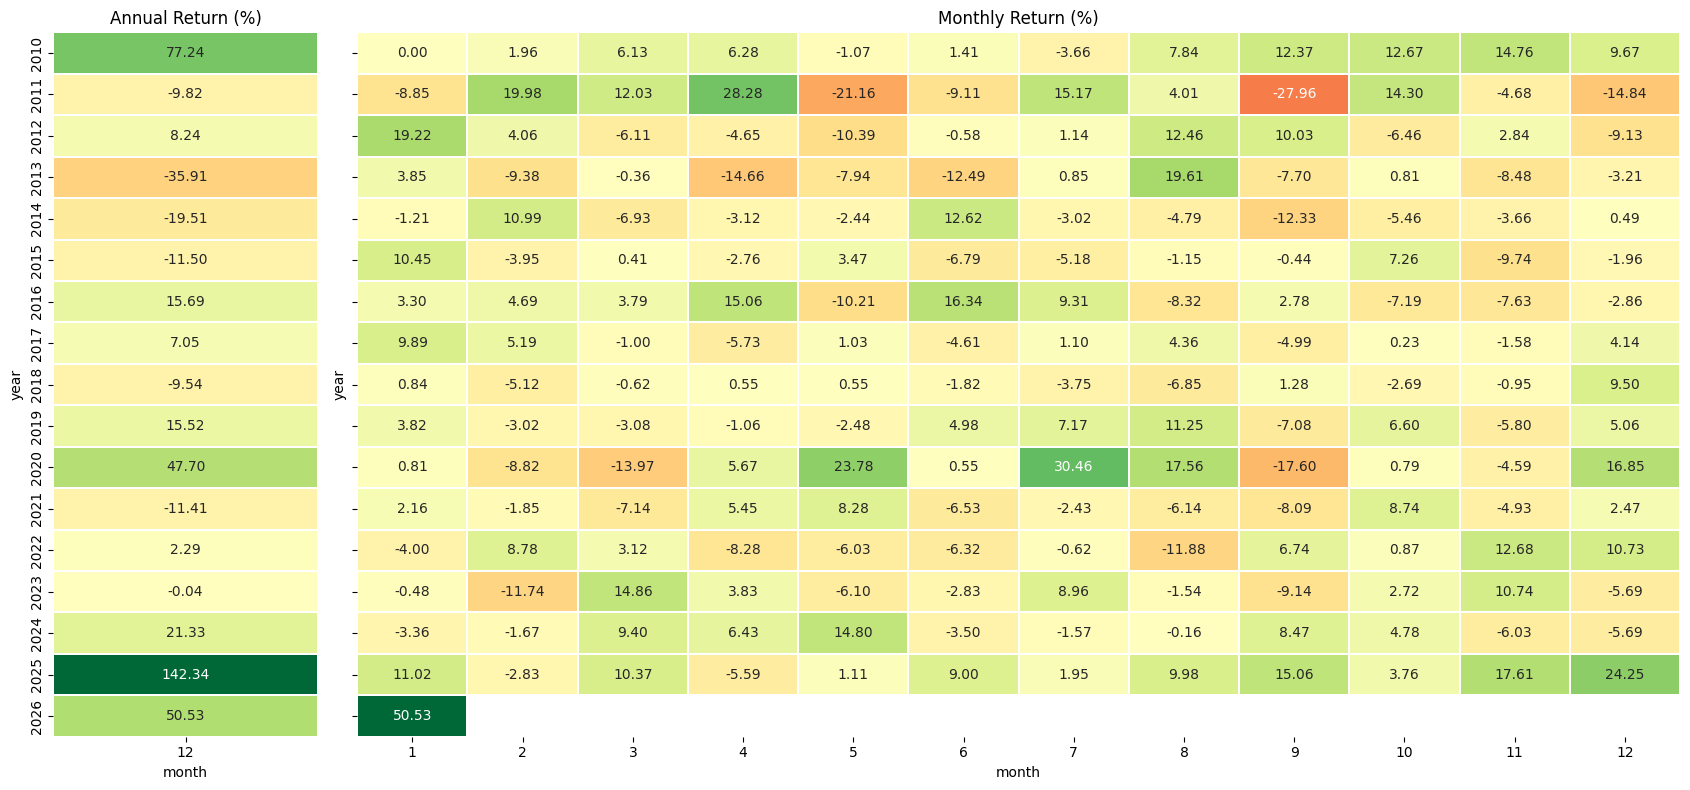

In [4]:
# SI=F: 은 선물 연결 지수 (Comex Silver Futures)
df = yf.download('SI=F', start='2010-01-01')

df['pct_change'] = df['Close'].pct_change().fillna(0)
df['cumReturn'] = (1 + df['pct_change']).cumprod()

get_heatmap(df['cumReturn'])

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yfinance as yf

# -----------------------------------------------------------
# 함수 정의 (암호화폐 특성에 맞춰 CAGR 계산일수 365로 변경)
# -----------------------------------------------------------
def get_heatmap(cumReturn):
    """
    cagr, dd, mdd 계산 및 히트맵(연간/월간 수익률) 시각화
    """
    if cumReturn.empty:
        print("데이터가 없습니다.")
        return

    # 데이터 개수가 365개 쌓여야 1년으로 치기 때문입니다.
    cagr = cumReturn.iloc[-1] ** (365/len(cumReturn))

    dd = (cumReturn.cummax() - cumReturn) / cumReturn.cummax() * 100
    mdd = dd.max()

    print(f"최종수익률: {cumReturn.iloc[-1]:.4f}")
    print(f"CAGR (연평균 성장률): {cagr:.4f}")
    print(f"MDD (최대 낙폭): {mdd:.4f}%")

    # 데이터프레임 변환 및 전처리
    cumReturn = pd.DataFrame(cumReturn)
    cumReturn.columns = ['cumReturn']
    cumReturn['year'] = cumReturn.index.year
    cumReturn['month'] = cumReturn.index.month

    # 월별/연별 마지막 데이터만 추출
    monthData = cumReturn.drop_duplicates(['year', 'month'], keep="last").copy()
    yearData = cumReturn.drop_duplicates('year', keep="last").copy()

    # 수익률 계산
    monthData['monthReturn'] = monthData['cumReturn'].pct_change().fillna(0) * 100
    yearData['yearReturn'] = yearData['cumReturn'].pct_change().fillna(0) * 100

    # 첫 해 수익률 보정 (1.0에서 시작했다고 가정)
    yearData.iloc[0, -1] = (yearData.iloc[0, 0] - 1) * 100

    # 시각화를 위해 마지막 데이터의 '월'을 강제로 12로 설정
    yearData.iloc[-1, yearData.columns.get_loc('month')] = 12

    # 히트맵 시각화용 피벗 테이블
    monthPivot = monthData.pivot(index='year', columns='month', values='monthReturn')
    yearPivot = yearData.pivot(index='year', columns='month', values='yearReturn')

    # 그래프 그리기
    f, (ax1, ax2) = plt.subplots(1, 2, sharey=True, gridspec_kw={'width_ratios': [1, 5]}, figsize=(20, 10))

    # 비트코인은 연간 수익률이 1000%를 넘기도 하므로,
    # 200%만 넘어도 '완전 대박(진한 초록)'으로 보이게 vmax를 제한합니다.
    sns.heatmap(yearPivot, ax=ax1, annot=True, fmt='.2f', linewidths=.3, cmap="RdYlGn", center=0, cbar=False,
                vmin=-100, vmax=200) # <- 여기를 조절하세요 (예: -80 ~ 150 등)
    ax1.set_title("Annual Return (%)")

    # [수정 포인트 2] 월간 수익률 히트맵
    # 월간은 변동폭이 연간보다 작으므로 범위를 좁게(-30% ~ +30%) 잡아야 색 대비가 뚜렷해집니다.
    sns.heatmap(monthPivot, ax=ax2, annot=True, fmt='.2f', linewidths=.1, cmap="RdYlGn", center=0, cbar=False,
                vmin=-30, vmax=30) # <- 월간 데이터에 맞는 범위 설정
    ax2.set_title("Monthly Return (%)")

    plt.tight_layout()
    plt.show()


[*********************100%***********************]  1 of 1 completed


최종수익률: 180.2171
CAGR (연평균 성장률): 1.5784
MDD (최대 낙폭): 83.3990%


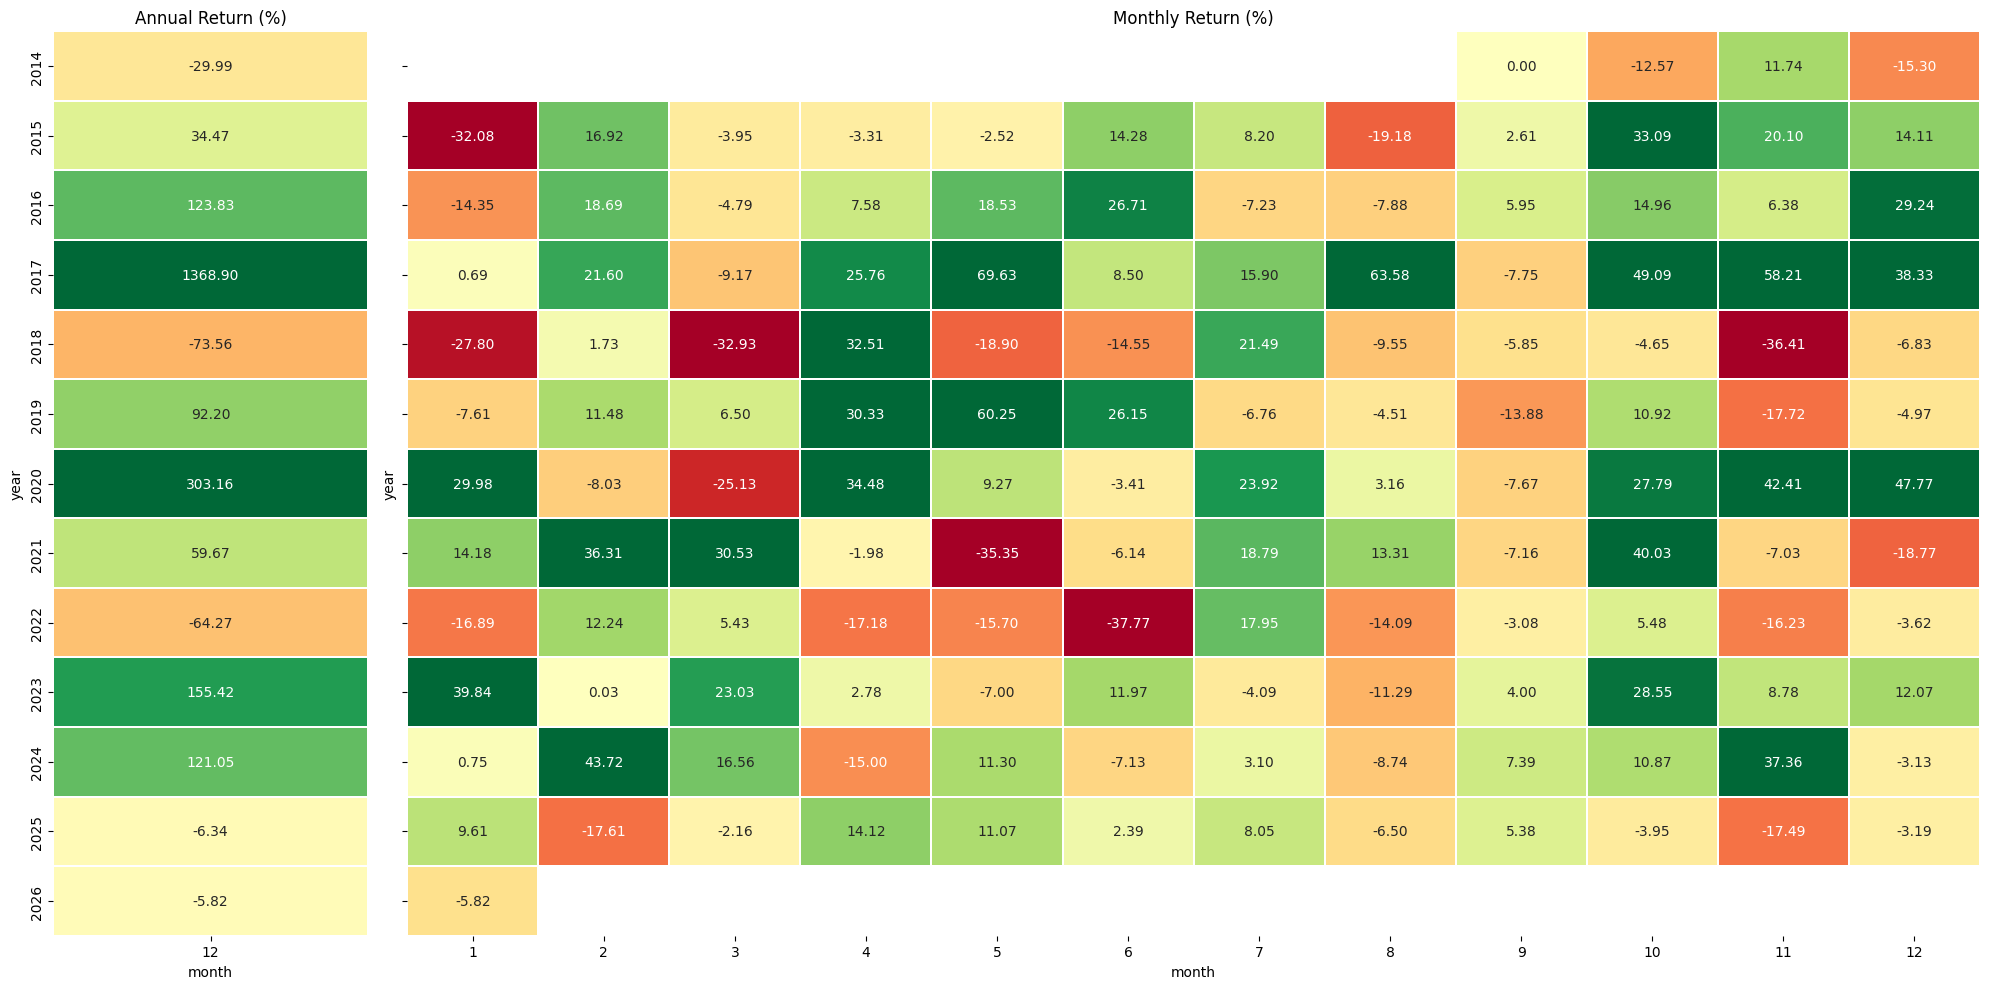

In [6]:
df = yf.download('BTC-USD', start='2010-01-01')

df['pct_change'] = df['Close'].pct_change().fillna(0)
df['cumReturn'] = (1 + df['pct_change']).cumprod()

get_heatmap(df['cumReturn'])